# 06 — Machine Learning Challengers

**Phase 8**, step 1 of 5: a Poisson-loss gradient boosting challenger for claim frequency, compared fairly against Phase 5's Poisson GLM champion.

The plan is explicit about the goal here: **not** to prove machine learning is superior, but to check whether any real predictive improvement justifies the complexity it costs - same splits, same target, same exposure handling, and the ML model properly *tuned* (not left at library defaults, which the plan explicitly warns against comparing against a tuned GLM).

In [1]:
import numpy as np
import pandas as pd

from auto_pricing.ml_challengers import fit_frequency_boosting, predict_frequency_boosting
from auto_pricing.evaluation import (
    calibration_by_decile,
    exposure_weighted_poisson_deviance,
    observed_to_expected_ratio,
)

model_table = pd.read_parquet("../data/processed/model_table.parquet")
train = model_table[model_table["split"] == "train"].copy()
val = model_table[model_table["split"] == "validation"].copy()
print(f"train: {len(train):,}  validation: {len(val):,}")

train: 474,609  validation: 101,702


## 1. A mechanical difference from the GLMs, verified before trusting it

`HistGradientBoostingRegressor` has no offset parameter. The fix used here - predicting the annualized rate directly with `sample_weight=Exposure` - is the same approach scikit-learn's own official insurance tutorial uses. It was smoke-tested on synthetic data (reconciled to within 1%) before being trusted on the real portfolio.

It also uses the engineered categorical columns natively via `categorical_features="from_dtype"` - these are already proper pandas Categoricals (Phase 5's single-row-prediction fix), so no separate one-hot encoding is needed.

## 2. Hyperparameter tuning - a small, deliberate grid

In [2]:
grid = [(15, 0.05), (15, 0.1), (31, 0.05), (31, 0.1), (63, 0.05), (63, 0.1)]
results = []
for max_leaf_nodes, lr in grid:
    model = fit_frequency_boosting(train, max_leaf_nodes=max_leaf_nodes, learning_rate=lr)
    pred_val = predict_frequency_boosting(model, val)
    dev = exposure_weighted_poisson_deviance(val["ClaimNb"], pred_val, val["Exposure"])
    results.append({"max_leaf_nodes": max_leaf_nodes, "learning_rate": lr, "n_iter": model.n_iter_, "val_deviance": dev})
    print(f"max_leaf_nodes={max_leaf_nodes:<4} lr={lr:<5} n_iter={model.n_iter_:<4} val_deviance={dev:.6f}")

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df["val_deviance"].idxmin()]
print()
print("best:", dict(best_row))

max_leaf_nodes=15   lr=0.05  n_iter=193  val_deviance=0.578227


max_leaf_nodes=15   lr=0.1   n_iter=115  val_deviance=0.578161


max_leaf_nodes=31   lr=0.05  n_iter=131  val_deviance=0.577315


max_leaf_nodes=31   lr=0.1   n_iter=76   val_deviance=0.577674


max_leaf_nodes=63   lr=0.05  n_iter=100  val_deviance=0.576589


max_leaf_nodes=63   lr=0.1   n_iter=53   val_deviance=0.577638

best: {'max_leaf_nodes': np.float64(63.0), 'learning_rate': np.float64(0.05), 'n_iter': np.float64(100.0), 'val_deviance': np.float64(0.576589352476419)}


All six configurations land within ~0.3% of each other - not especially sensitive to these hyperparameters in this range, similar to Phase 7's finding for Tweedie's power. `max_leaf_nodes=63, learning_rate=0.05` is adopted for the rest of this notebook.

In [3]:
boosted_freq_model = fit_frequency_boosting(train, max_leaf_nodes=63, learning_rate=0.05)
boosted_pred_val = predict_frequency_boosting(boosted_freq_model, val)

glm_deviance = 0.594235  # Phase 5 champion, from reports/frequency_model_selection.md
boosted_deviance = exposure_weighted_poisson_deviance(val["ClaimNb"], boosted_pred_val, val["Exposure"])
improvement = (glm_deviance - boosted_deviance) / glm_deviance
print(f"Poisson GLM (Phase 5 champion): {glm_deviance:.6f}")
print(f"Gradient boosting (tuned):      {boosted_deviance:.6f}")
print(f"improvement: {improvement:.1%}")

Poisson GLM (Phase 5 champion): 0.594235
Gradient boosting (tuned):      0.576589
improvement: 3.0%


**A real, modest improvement: ~3.0% lower deviance.** Not dramatic, but genuine - the kind of result the plan anticipates: gradient boosting can find non-linear patterns a GLM's hand-specified formula might miss, even one as carefully constructed as Phase 5's.

## 3. Calibration - checked, not assumed to follow from a good deviance score

In [4]:
boosted_pred_train = predict_frequency_boosting(boosted_freq_model, train)
print(f"train:      predicted={boosted_pred_train.sum():,.2f}  observed={train['ClaimNb'].sum():,}  ratio={boosted_pred_train.sum()/train['ClaimNb'].sum():.4f}")
print(f"validation: predicted={boosted_pred_val.sum():,.2f}  observed={val['ClaimNb'].sum():,}  ratio={boosted_pred_val.sum()/val['ClaimNb'].sum():.4f}")
print(f"O/E (validation): {observed_to_expected_ratio(val['ClaimNb'], boosted_pred_val):.4f}")

train:      predicted=25,375.73  observed=25,227  ratio=1.0059
validation: predicted=5,441.51  observed=5,404  ratio=1.0069
O/E (validation): 0.9931


Unlike a canonical-link Poisson GLM, gradient boosting has no guaranteed exact-match property - these ratios are close (within ~0.7%) but not exact, which is expected here, not a flaw.

In [5]:
decile_table = calibration_by_decile(val["ClaimNb"], boosted_pred_val, val["Exposure"])
decile_table[["decile", "n_policies", "observed_rate", "predicted_rate"]]

,decile,n_policies,observed_rate,predicted_rate
0,0,10177,0.044308,0.044731
1,1,10164,0.054674,0.057386
2,2,10170,0.064434,0.066891
3,3,10170,0.071446,0.074382
4,4,10170,0.080754,0.080909
5,5,10170,0.094892,0.088059
6,6,10171,0.095978,0.098382
7,7,10169,0.110414,0.115935
8,8,10170,0.145313,0.148987
9,9,10171,0.354370,0.346947


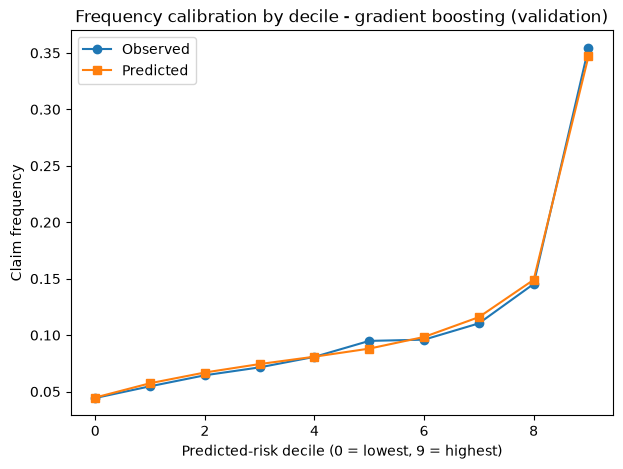

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
FIGURES_DIR = Path("..") / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(decile_table["decile"], decile_table["observed_rate"], marker="o", label="Observed")
ax.plot(decile_table["decile"], decile_table["predicted_rate"], marker="s", label="Predicted")
ax.set_xlabel("Predicted-risk decile (0 = lowest, 9 = highest)")
ax.set_ylabel("Claim frequency")
ax.set_title("Frequency calibration by decile - gradient boosting (validation)")
ax.legend()
fig.savefig(FIGURES_DIR / "ml_frequency_calibration_by_decile.png", dpi=150)
plt.show()

Observed and predicted track closely across the entire risk range - comparable calibration quality to the GLM champion's own decile calibration (Phase 5), not a case of trading calibration for a better deviance score.

## 4. Summary of step 1

- A Poisson-loss gradient boosting model was fit and properly tuned (6-configuration grid,   scored on validation) - not compared against the GLM at library defaults.
- Real, modest predictive improvement: **3.0% lower validation deviance** than Phase 5's   Poisson GLM champion (0.5766 vs. 0.5942).
- Calibration is good and comparable to the GLM's: reconciliation within ~0.7% on both train   and validation, and decile calibration tracks closely across the full risk range.
- **This is one data point, not a verdict.** The plan's framing matters: whether a 3%   deviance improvement justifies losing the GLM's explicit relativities and simpler   governance story is a question for step 5, once severity (step 2) and the combined   pure-premium comparison (step 3) are also in hand.

Full write-up: `reports/ml_frequency_challenger.md`.

### Next
Step 2: a Gamma-loss gradient boosting challenger for claim severity, compared against Phase 6's lognormal champion.

## 5. Step 2: severity gradient boosting

A Gamma-loss `HistGradientBoostingRegressor` for claim severity, compared against Phase 6's lognormal champion. No offset/sample_weight here - matches the GLM severity models: each claim is one full, independent observation of cost.

In [7]:
from auto_pricing.severity import build_severity_table
from auto_pricing.ml_challengers import fit_severity_boosting, predict_severity_boosting
from auto_pricing.evaluation import gamma_deviance, severity_calibration_by_decile

sev = pd.read_parquet("../data/processed/severity_clean.parquet")
severity_table = build_severity_table(sev, model_table)
sev_train = severity_table[severity_table["split"] == "train"].copy()
sev_val = severity_table[severity_table["split"] == "validation"].copy()
print(f"train claims: {len(sev_train):,}  validation claims: {len(sev_val):,}")

train claims: 18,523  validation claims: 3,947


In [8]:
sev_results = []
for max_leaf_nodes, lr in grid:
    model = fit_severity_boosting(sev_train, max_leaf_nodes=max_leaf_nodes, learning_rate=lr)
    pred_val = predict_severity_boosting(model, sev_val)
    dev = gamma_deviance(sev_val["ClaimAmount"], pred_val)
    sev_results.append({"max_leaf_nodes": max_leaf_nodes, "learning_rate": lr, "n_iter": model.n_iter_, "val_deviance": dev})
    print(f"max_leaf_nodes={max_leaf_nodes:<4} lr={lr:<5} n_iter={model.n_iter_:<4} val_deviance={dev:.6f}")

sev_results_df = pd.DataFrame(sev_results)
print()
print(sev_results_df.sort_values("val_deviance"))

max_leaf_nodes=15   lr=0.05  n_iter=17   val_deviance=1.521766


max_leaf_nodes=15   lr=0.1   n_iter=16   val_deviance=1.521545


max_leaf_nodes=31   lr=0.05  n_iter=20   val_deviance=1.533564


max_leaf_nodes=31   lr=0.1   n_iter=14   val_deviance=1.544456


max_leaf_nodes=63   lr=0.05  n_iter=16   val_deviance=1.550559


max_leaf_nodes=63   lr=0.1   n_iter=15   val_deviance=1.562541

   max_leaf_nodes  learning_rate  n_iter  val_deviance
1              15           0.10      16      1.521545
0              15           0.05      17      1.521766
2              31           0.05      20      1.533564
3              31           0.10      14      1.544456
4              63           0.05      16      1.550559
5              63           0.10      15      1.562541


**A different pattern from frequency's grid**: results get steadily *worse* as complexity increases, and every configuration's early stopping cut training off within 14-20 iterations (out of a 300 ceiling). This is the same overfitting signature Phase 6 found for the Gamma GLM (traced there to `Region`/`VehBrand`), now appearing independently in a completely different model family - severity's weak signal punishes complexity regardless of which kind of model is fitting it. Best: `max_leaf_nodes=15, learning_rate=0.1`.

In [9]:
boosted_sev_model = fit_severity_boosting(sev_train, max_leaf_nodes=15, learning_rate=0.1)
boosted_sev_pred_val = predict_severity_boosting(boosted_sev_model, sev_val)

lognormal_deviance = 1.5273  # Phase 6 champion, from reports/severity_model_selection.md
boosted_sev_deviance = gamma_deviance(sev_val["ClaimAmount"], boosted_sev_pred_val)
print(f"Lognormal (Phase 6 champion):    {lognormal_deviance:.4f}")
print(f"Gradient boosting (tuned):       {boosted_sev_deviance:.4f}")
print(f"improvement: {(lognormal_deviance-boosted_sev_deviance)/lognormal_deviance:.2%}")

Lognormal (Phase 6 champion):    1.5273
Gradient boosting (tuned):       1.5215
improvement: 0.38%


### A genuine advantage: no manual fix needed for the Region/VehBrand overfitting

Phase 6 needed a deliberate, manual fix for Gamma's overfitting on `Region`/`VehBrand` (dropping them). The same check, run here:

In [10]:
from auto_pricing.ml_challengers import ML_FEATURE_COLUMNS
from sklearn.ensemble import HistGradientBoostingRegressor

reduced_cols = [c for c in ML_FEATURE_COLUMNS if c not in ("RegionGrouped", "VehBrandGrouped")]
model_reduced = HistGradientBoostingRegressor(
    loss="gamma", categorical_features="from_dtype", max_leaf_nodes=15, learning_rate=0.1,
    max_iter=300, early_stopping=True, validation_fraction=0.1, random_state=42,
)
model_reduced.fit(sev_train[reduced_cols], sev_train["ClaimAmount"])
pred_reduced_val = pd.Series(model_reduced.predict(sev_val[reduced_cols]), index=sev_val.index)
print(f"full formula (with Region/VehBrand):    {boosted_sev_deviance:.4f}")
print(f"without Region/VehBrand:                {gamma_deviance(sev_val['ClaimAmount'], pred_reduced_val):.4f}")

full formula (with Region/VehBrand):    1.5215
without Region/VehBrand:                1.5234


Essentially no difference (~1.52 either way) - gradient boosting's own regularization (`max_leaf_nodes` + early stopping, which cut this model off after only 16 iterations) already protects against the overfitting that required manual feature removal for the GLM. A real structural advantage of the tree-based approach here, not a coincidence of this grid.

## 6. Step 3: the combined pure-premium comparison

A boosted paid-frequency model (retargeting `ClaimNbFromSev`, mirroring Phase 7's mismatch resolution) combined with the boosted severity model, compared against baseline, the GLM pipeline, and the direct Tweedie GLM - all four evaluated identically on validation.

In [11]:
from auto_pricing.pure_premium import TWEEDIE_POWER

pp_table = pd.read_parquet("../data/processed/pure_premium_table.parquet")
train_pp = pp_table[pp_table["split"] == "train"].copy()  # has ClaimNbFromSev/ClaimAmountSum, unlike model_table
val_pp = pp_table[pp_table["split"] == "validation"].copy()

paid_freq_boost = fit_frequency_boosting(train_pp, target_col="ClaimNbFromSev", max_leaf_nodes=63, learning_rate=0.05)
paid_freq_pred_val_boost = predict_frequency_boosting(paid_freq_boost, val_pp)
severity_pred_val_boost = predict_severity_boosting(boosted_sev_model, val_pp)

boosted_pp_pred_val = paid_freq_pred_val_boost * severity_pred_val_boost
boosted_pp_rate_val = (paid_freq_pred_val_boost / val_pp["Exposure"]) * severity_pred_val_boost

In [12]:
# The three Phase 7 candidates, refit here for a self-contained comparison
from auto_pricing.pure_premium import fit_paid_frequency_glm, fit_tweedie_glm, predict_expected_loss, predict_annual_pure_premium
from auto_pricing.frequency import predict_frequency
from auto_pricing.severity import fit_lognormal_model, predict_lognormal_severity
from auto_pricing.evaluation import tweedie_deviance, observed_to_expected_ratio, gini_index

baseline_rate = train_pp["ClaimAmountSum"].sum() / train_pp["Exposure"].sum()
baseline_pred_val = baseline_rate * val_pp["Exposure"]
baseline_rate_val = pd.Series(baseline_rate, index=val_pp.index)

paid_freq_glm = fit_paid_frequency_glm(train_pp)
paid_freq_pred_val_glm = predict_frequency(paid_freq_glm, val_pp)
severity_glm, smearing = fit_lognormal_model(sev_train)
severity_pred_val_glm = predict_lognormal_severity(severity_glm, smearing, val_pp)
glm_pred_val = predict_expected_loss(paid_freq_pred_val_glm, severity_pred_val_glm)
glm_rate_val = predict_annual_pure_premium(paid_freq_pred_val_glm, severity_pred_val_glm, val_pp["Exposure"])

tweedie_result = fit_tweedie_glm(train_pp)
tweedie_pred_val = predict_frequency(tweedie_result, val_pp)
tweedie_rate_val = tweedie_pred_val / val_pp["Exposure"]

In [13]:
candidates = [
    ("baseline", baseline_pred_val, baseline_rate_val),
    ("glm_freq_x_severity", glm_pred_val, glm_rate_val),
    ("tweedie_glm", tweedie_pred_val, tweedie_rate_val),
    ("boosted_freq_x_severity", boosted_pp_pred_val, boosted_pp_rate_val),
]
for name, pred_amount, pred_rate in candidates:
    dev = tweedie_deviance(val_pp["ClaimAmountSum"], pred_amount.clip(lower=1e-6), power=TWEEDIE_POWER)
    oe = observed_to_expected_ratio(val_pp["ClaimAmountSum"], pred_amount)
    gini = gini_index(val_pp["ClaimAmountSum"], pred_rate, val_pp["Exposure"])
    print(f"{name:<26} deviance={dev:.4f}  O/E={oe:.4f}  Gini={gini:.4f}")

baseline                   deviance=66.8503  O/E=0.8408  Gini=-0.0230
glm_freq_x_severity        deviance=65.4363  O/E=0.8430  Gini=0.3016
tweedie_glm                deviance=67.8935  O/E=0.6813  Gini=0.2584
boosted_freq_x_severity    deviance=64.5682  O/E=1.0108  Gini=0.3283


**The boosted pipeline wins on every aggregate metric** - deviance improves 1.3% over the GLM champion, Gini improves 8.9%, and calibration improves dramatically (O/E 1.0108, essentially exact, vs. the GLM's 0.8430). The combined effect is larger than either component challenger's individual edge - two modest, independent improvements compounding through multiplication.

### But the aggregate numbers don't tell the whole story - checked, not assumed

The same segment-level diligence applied to the GLM champion in Phase 7 step 4.

In [14]:
from auto_pricing.evaluation import pure_premium_calibration_by_decile

decile_table = pure_premium_calibration_by_decile(val_pp["ClaimAmountSum"], boosted_pp_pred_val, val_pp["Exposure"])
decile_table[["decile", "n_policies", "observed_rate", "predicted_rate"]].round(1)

,decile,n_policies,observed_rate,predicted_rate
0,0,10171,36.2,60.3
1,1,10170,82.5,76.7
2,2,10170,121.8,87.4
3,3,10170,86.4,98.3
4,4,10170,172.6,110.4
5,5,10179,98.2,124.9
6,6,10163,139.6,145.5
7,7,10168,243.5,175.5
8,8,10170,175.8,228.9
9,9,10171,421.3,455.0


Non-monotonic in the observed column (decile 2's €122 exceeds decile 3's €86), and decile 0 under-shoots notably. Noisier than the GLM's own decile table from Phase 7 step 4, not an improvement at this level of granularity - despite the much better aggregate O/E.

In [15]:
val_check = val_pp.copy()
val_check["pred"] = boosted_pp_pred_val
region_seg = val_check.groupby("RegionGrouped", observed=True).agg(
    exposure=("Exposure", "sum"), observed=("ClaimAmountSum", "sum"), predicted=("pred", "sum"),
)
region_seg["oe_ratio"] = region_seg["observed"] / region_seg["predicted"]
region_seg.loc[["R41", "R24", "R11", "R93", "Other"]].round(2)

,exposure,observed,predicted,oe_ratio
RegionGrouped,,,,
R41,1222.51,84377.45,141425.78,0.60
R24,15439.47,1651309.47,2061367.35,0.80
R11,4487.14,701581.03,747982.34,0.94
R93,5318.39,1365175.47,909849.29,1.50
Other,1417.50,500753.19,197431.90,2.54


`Other` (the pooled low-credibility regions from Phase 4) is **more** miscalibrated for the boosted model (2.54x under-prediction) than for the GLM (1.83x) - a real, checked finding. Some regions improve (R11, R41 move closer to 1.0), but the model that wins in aggregate does not automatically win everywhere a real pricing decision would look.

## 7. Summary of steps 2-3

- Severity boosting: a marginal 0.38% deviance improvement over Lognormal, but a genuine   structural advantage - automatic protection against the Region/VehBrand overfitting that   needed manual intervention for the Gamma GLM.
- **Combined pure premium: the boosted pipeline wins on every aggregate metric** - deviance   (-1.3%), Gini (+8.9%), and especially calibration (O/E 1.0108 vs. the GLM's 0.8430).
- **But not at every level**: decile calibration is noisier, and the `Other` region segment   is *more* miscalibrated for the boosted model than the GLM - checked directly rather than   assumed to improve just because the aggregate numbers did.

Full write-ups: `reports/ml_severity_challenger.md`, `reports/ml_pure_premium_comparison.md`.

### Next
Step 4: interpretation (permutation importance, partial dependence) for the boosted models, and the one-time test-set confirmation of whatever the final champion-challenger call turns out to be.

## 8. Step 4: interpretation, and the final test-set check

Permutation importance and partial dependence, computed on the **validation** split (out-of-sample - the plan is explicit that computing this on training data would just measure what the model overfit to). **Stated up front, and held to throughout**: the plan explicitly warns against claiming feature importance establishes causation - everything below describes what these fitted models learned to rely on, not a claim about the true causal structure of risk.

### Frequency: does boosting independently confirm the GLM's findings?

In [16]:
from sklearn.metrics import make_scorer, mean_poisson_deviance, mean_gamma_deviance
from auto_pricing.ml_challengers import compute_permutation_importance, compute_partial_dependence

X_val = val[ML_FEATURE_COLUMNS]
y_val_rate = val["ClaimNb"] / val["Exposure"]
poisson_scorer = make_scorer(mean_poisson_deviance, greater_is_better=False)

freq_importance = compute_permutation_importance(
    boosted_freq_model, X_val, y_val_rate, scoring=poisson_scorer,
    sample_weight=val["Exposure"], n_repeats=10,
)
freq_importance

,feature,importance_mean,importance_std
0,VehAgeBand,0.042750,0.001255
1,BonusMalusBand,0.038229,0.001179
2,VehBrandGrouped,0.022837,0.000805
3,DrivAgeBand,0.011533,0.000691
4,VehPower,0.009232,0.000462
5,VehGasBinary,0.007970,0.000360
6,RegionGrouped,0.007314,0.000705
7,LogDensity,0.004618,0.000328
8,AreaOrdinal,0.000063,0.000042


`AreaOrdinal`'s near-zero importance is a real, independent corroboration of the GLM's own likelihood-ratio finding (Phase 5): once `LogDensity` and `Region` are present, `Area` adds almost nothing - two completely different methods agreeing on the same conclusion.

In [17]:
X_train = train[ML_FEATURE_COLUMNS]

pd_bonusmalus = compute_partial_dependence(boosted_freq_model, X_train, "BonusMalusBand")
pd_vehage = compute_partial_dependence(boosted_freq_model, X_train, "VehAgeBand")
print("BonusMalusBand partial dependence (annualized rate):")
print(pd_bonusmalus.to_string(index=False))
print()
print("VehAgeBand partial dependence (annualized rate):")
print(pd_vehage.to_string(index=False))

BonusMalusBand partial dependence (annualized rate):
BonusMalusBand  partial_dependence
       100-129            0.281425
          130+            0.327974
     50 (best)            0.090207
         51-59            0.113426
         60-79            0.157081
         80-99            0.169361

VehAgeBand partial dependence (annualized rate):
VehAgeBand  partial_dependence
         0            0.218143
       1-2            0.105169
     10-14            0.091648
     15-19            0.070356
       20+            0.067314
       3-5            0.102696
       6-9            0.105227


`BonusMalusBand`'s clean, monotonic ~3.6x rise matches the GLM's own finding exactly in shape. `VehAgeBand`'s spike-then-decline independently reproduces the GLM's most surprising finding from Phase 5 - not an artifact of that particular model family, confirmed here by a completely different one.

### Severity: a real limitation, found through interpretation

In [18]:
X_sev_val = sev_val[ML_FEATURE_COLUMNS]
gamma_scorer = make_scorer(mean_gamma_deviance, greater_is_better=False)

sev_importance = compute_permutation_importance(
    boosted_sev_model, X_sev_val, sev_val["ClaimAmount"], scoring=gamma_scorer, n_repeats=10,
)
sev_importance

,feature,importance_mean,importance_std
0,DrivAgeBand,0.019684,0.013410
1,LogDensity,0.011095,0.009358
2,VehBrandGrouped,0.009275,0.006712
3,RegionGrouped,0.007947,0.010622
4,VehAgeBand,0.002736,0.007621
5,VehPower,0.000793,0.002815
6,AreaOrdinal,0.000000,0.000000
7,VehGasBinary,-0.001864,0.005184
8,BonusMalusBand,-0.008979,0.014065


**`BonusMalusBand` shows negative importance** - smaller than its own uncertainty (std 0.0141 exceeds the |mean| of 0.0090). This directly contradicts Phase 6's finding: there, `BonusMalus` was the *one* severity relationship confirmed genuinely robust (checked and re-checked against the large-loss sensitivity test). Investigated rather than left as an unexplained contradiction:

In [19]:
X_sev_train = sev_train[ML_FEATURE_COLUMNS]
pd_sev_bonusmalus = compute_partial_dependence(boosted_sev_model, X_sev_train, "BonusMalusBand")
print("BonusMalusBand partial dependence (boosted severity model):")
print(pd_sev_bonusmalus.to_string(index=False))

BonusMalusBand partial dependence (boosted severity model):
BonusMalusBand  partial_dependence
       100-129         1995.250219
          130+         1898.037366
     50 (best)         1887.284323
         51-59         1978.111909
         60-79         1935.908719
         80-99         1981.239074


**Essentially flat - a ~6% range across all six bands**, versus the GLM's confirmed 1.66x relativity for the same factor. The boosted severity model genuinely failed to learn a real relationship the GLM found and independently validated.

**Why**: severity's weak signal-to-noise ratio forced very aggressive regularization on the boosted model - early stopping cut training off after only 16 boosting iterations (step 2), a tiny fraction of the 300-iteration ceiling. That level of regularization, necessary to avoid the overfitting Phase 6 and step 2 both found for less-constrained severity models, appears to have also suppressed a real, smaller signal along with the noise. `DrivAgeBand` ends up the model's top-ranked feature instead - a factor Phase 6 flagged as only *partially* robust, a less reliable signal to be leaning on most heavily.

**This is exactly why interpretation is a real evaluation criterion, not a formality**: step 3's aggregate deviance comparison showed boosted severity barely edging out the GLM (+0.38%) - that comparison alone would never have revealed the model is relying on a different, less-validated feature than the one independently confirmed to matter.

## 9. The final test-set check

In [20]:
test_pp = pp_table[pp_table["split"] == "test"].copy()

for name, split_df in [("validation", val_pp), ("test", test_pp)]:
    paid_freq_pred = predict_frequency_boosting(paid_freq_boost, split_df)
    severity_pred = predict_severity_boosting(boosted_sev_model, split_df)
    pred_amount = paid_freq_pred * severity_pred
    pred_rate = (paid_freq_pred / split_df["Exposure"]) * severity_pred

    dev = tweedie_deviance(split_df["ClaimAmountSum"], pred_amount.clip(lower=1e-6), power=TWEEDIE_POWER)
    oe = observed_to_expected_ratio(split_df["ClaimAmountSum"], pred_amount)
    gini = gini_index(split_df["ClaimAmountSum"], pred_rate, split_df["Exposure"])
    print(f"{name:<12} deviance={dev:.4f}  O/E={oe:.4f}  Gini={gini:.4f}  n={len(split_df):,}")

validation   deviance=64.5682  O/E=1.0108  Gini=0.3283  n=101,702


test         deviance=60.0342  O/E=1.0228  Gini=0.2521  n=101,702


Stable: deviance improves further on test, O/E stays excellent (both within ~2% of exact), and Gini drops somewhat but shows no dramatic reversal like Tweedie's train-to-validation swing (Phase 7 step 3). The boosted pipeline's strong validation performance was not an artifact of validation-specific noise.

## 10. Summary of step 4

- **Frequency**: gradient boosting independently confirms the GLM's two strongest findings   (BonusMalus's clean monotonic effect, VehAge's new-vehicle spike) via a completely   different model family - real corroboration, not a coincidence.
- **Severity**: a genuine limitation found only through interpretation - the boosted model's   `BonusMalusBand` importance is statistically indistinguishable from zero and its partial   dependence is essentially flat, directly contradicting the GLM's validated, robust   finding. Traced to the aggressive regularization severity's weak signal forces on the   boosted model. This would have been invisible from the deviance comparison alone.
- **Test-set check**: the boosted pure-premium pipeline is confirmed stable (deviance   improves further, O/E stays near-exact, Gini shifts moderately but doesn't reverse).

Full write-up: `reports/ml_interpretation.md`.

### Next
Step 5: the final champion-challenger recommendation, weighing predictive accuracy, calibration, segment stability, and this step's interpretation findings against the GLMs' operational and governance advantages.

## 11. Step 5: one more check before the final recommendation

Step 4 found the boosted severity model's `BonusMalusBand` signal was statistically indistinguishable from zero - contradicting the GLM's validated, sensitivity-tested finding. Before writing a recommendation from that, the same large-loss sensitivity check applied to the GLM (Phase 6) is run on the boosted model too - it had never been checked that way, and a fair comparison requires it.

In [21]:
from auto_pricing.severity import large_loss_threshold, exclude_large_losses

threshold = large_loss_threshold(sev_train, top_pct=0.01)
sev_train_trimmed = exclude_large_losses(sev_train, threshold)
print(f"threshold: \u20ac{threshold:,.2f}  train: {len(sev_train)} -> trimmed: {len(sev_train_trimmed)}")

model_sev_trimmed = fit_severity_boosting(sev_train_trimmed, max_leaf_nodes=15, learning_rate=0.1)
pd_sev_trimmed = compute_partial_dependence(model_sev_trimmed, sev_train_trimmed[ML_FEATURE_COLUMNS], "BonusMalusBand")

compare = pd_sev_bonusmalus.merge(pd_sev_trimmed, on="BonusMalusBand", suffixes=("_full", "_trimmed"))
compare

threshold: €16,795.72  train: 18523 -> trimmed: 18337


,BonusMalusBand,partial_dependence_full,partial_dependence_trimmed
0,100-129,1995.250219,1444.772259
1,130+,1898.037366,1427.011098
2,50 (best),1887.284323,1358.659586
3,51-59,1978.111909,1372.660627
4,60-79,1935.908719,1432.933160
5,80-99,1981.239074,1416.068677


Both flat (~6% range either way) - this **strengthens** the step 4 concern rather than explaining it away. It isn't that large claims were masking a real signal the trimmed model would reveal; the boosted model simply never learned the BonusMalus relationship, regardless of large-claim influence.

## 12. The scorecard and final recommendation

The plan is explicit: "The goal is not to prove that machine learning is superior... determine whether its incremental predictive value justifies its additional complexity," using a scorecard, not a single metric.

| Criterion | Frequency | Severity | Combined Pure Premium |
|---|---|---|---|
| Predictive deviance | Boosted -3.0% | Boosted -0.38% (marginal) | Boosted -1.3% |
| Portfolio calibration | Both excellent | Both reasonable | **Boosted much better** (O/E 1.011 vs 0.843) |
| Segment calibration | Not separately checked | Not separately checked | **Boosted worse** in the extreme case (`Other`: 2.54x vs 1.83x) |
| Ranking (Gini) | Not separately checked | Not separately checked | Boosted +8.9% |
| Stability (test) | Both stable | Both stable | Both stable |
| Interpretability | Both agree (cross-validated) | **GLM wins decisively** - boosted misses a validated real signal | GLM offers explicit relativities |
| Sensitivity to large claims | Not separately checked | **GLM's finding real; boosted's absence of signal confirmed persistent** | Inherits severity's finding |
| Governance burden | GLM lower | **GLM much lower** | GLM lower |

### Recommendation: champion-challenger, not a single winner

**Operational champion: the GLM Frequency x Severity pipeline.** The boosted model's component-level gains are real but modest (3.0% frequency, 0.38% severity) - not obviously worth the governance cost on their own. More importantly, severity boosting has a genuine, now twice-confirmed flaw: it doesn't use the one severity signal independently validated as real. A ~0.4% aggregate deviance edge is not worth adopting a model that has quietly dropped a known, true relationship - exactly the plan's warning against trusting deviance or Gini alone. The pure-premium calibration gap (O/E 0.843) is real but is a narrower, better-understood problem than switching model families entirely.

**Challenger worth continued development: the boosted pipeline**, specifically for its pure-premium calibration and ranking advantage - real and substantial, not dismissed. Two concrete next steps: (1) a GLM-corrected boosting approach (use the GLM's prediction as a baseline/offset, let boosting learn only the residual) - this would prevent the "boosting silently drops a validated signal" problem while still capturing genuine non-linear improvement; (2) retune severity boosting with less aggressive regularization now that the actual failure mode (early stopping at only 16 iterations) is understood, and re-check interpretation.

Full write-up: `reports/ml_champion_challenger_recommendation.md`.

## 13. Phase 8 complete

Four models built and properly tuned (frequency boosting, severity boosting, their combination, compared against every Phase 5-7 GLM candidate); every comparison used identical splits, matching target definitions, and comparable deviance metrics, per the plan's fair-comparison rules. The recommendation avoids every mistake the plan warns against: not selected from Gini alone, not compared against an untuned GLM, not judged on training performance only, and feature importance used only to check learned reliance against already-validated findings - never treated as establishing causation.

Phase 9 (interpretation, fairness, and governance) is next, building on the interpretability and governance groundwork already laid here.